In [ ]:
import json
import pickle
from pathlib import Path
from typing import Dict, List, Optional
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")
BASE_ARTIFACTS_DIR = Path("artifacts")
OUTPUT_DIR = Path("notebook/outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Artifacts root: {BASE_ARTIFACTS_DIR.resolve()}")
print(f"Outputs will be saved to: {OUTPUT_DIR.resolve()}")

Artifacts root: /Users/samuel/nfl-model-platform/artifacts
Outputs will be saved to: /Users/samuel/nfl-model-platform/notebook/outputs


In [26]:
def find_artifact_dirs(base_dir: Path = BASE_ARTIFACTS_DIR) -> List[Path]:
    if not base_dir.exists():
        print(f"No artifacts directory found at {base_dir.resolve()}")
        return []
    runs: List[Path] = []
    for model_dir in base_dir.iterdir():
        if model_dir.is_dir():
            for version_dir in model_dir.iterdir():
                if version_dir.is_dir():
                    runs.append(version_dir)
    return sorted(runs)


def _metric_from_metadata(meta: Dict[str, object]) -> Dict[str, object]:
    metric_keys = [
        "holdout_rmse",
        "holdout_mae",
        "baseline_rmse",
        "best_cv_rmse",
        "beat_baseline",
    ]
    metrics = {k: meta.get(k) for k in metric_keys if k in meta}
    metrics["train_rows"] = meta.get("train_rows")
    metrics["holdout_rows"] = meta.get("holdout_rows")
    metrics["n_estimators"] = meta.get("n_estimators")
    return metrics


def load_metadata(artifact_dir: Path) -> Optional[Dict[str, object]]:
    meta_path = artifact_dir / "metadata.json"
    if not meta_path.exists():
        print(f"No metadata.json found in {artifact_dir}")
        return None
    with meta_path.open() as f:
        meta = json.load(f)
    meta["artifact_dir"] = str(artifact_dir)
    meta.setdefault("model_name", artifact_dir.parent.name)
    meta.setdefault("version", artifact_dir.name)
    return meta


def load_model(artifact_dir: Path):
    model_path = artifact_dir / "model.pkl"
    if not model_path.exists():
        print(f"No model.pkl found in {artifact_dir}")
        return None
    with model_path.open("rb") as f:
        return pickle.load(f)


def metadata_row(meta: Dict[str, object]) -> pd.DataFrame:
    metrics = _metric_from_metadata(meta)
    row = {
        "model_name": meta.get("model_name"),
        "version": meta.get("version"),
        "saved_at": meta.get("saved_at"),
        **metrics,
    }
    best_params = meta.get("best_params")
    if isinstance(best_params, dict):
        row["best_params"] = json.dumps(best_params)
    return pd.DataFrame([row])


def load_eval_results(artifact_dir: Path) -> pd.DataFrame:
    candidates = [
        artifact_dir / "evaluation.json",
        artifact_dir / "eval.json",
        artifact_dir / "metrics.json",
        artifact_dir / "metrics.csv",
    ]
    for path in candidates:
        if path.exists():
            if path.suffix == ".csv":
                df = pd.read_csv(path)
            else:
                with path.open() as f:
                    payload = json.load(f)
                if isinstance(payload, list):
                    df = pd.DataFrame(payload)
                else:
                    df = pd.DataFrame([payload])
            df["artifact_dir"] = str(artifact_dir)
            return df
    meta = load_metadata(artifact_dir)
    if meta is None:
        return pd.DataFrame()
    metrics = _metric_from_metadata(meta)
    tidy = pd.DataFrame(
        [
            {"metric": k, "value": v, "artifact_dir": str(artifact_dir)}
            for k, v in metrics.items()
            if v is not None
        ]
    )
    return tidy

In [ ]:
artifact_dirs = find_artifact_dirs()
print(f"Found {len(artifact_dirs)} artifact runs:")
for idx, run in enumerate(artifact_dirs, 1):
    meta = load_metadata(run) or {}
    mode = meta.get("mode", "unknown")
    rmse = meta.get("holdout_rmse", "?")
    print(f"  {idx:02d}: {run}  [{mode}]  holdout_rmse={rmse}")

# Default: use the last (most recent) artifact for single-run cells
selected_artifact_dir = artifact_dirs[-1] if artifact_dirs else BASE_ARTIFACTS_DIR
print(f"\nSelected (default): {selected_artifact_dir}")

Found 7 artifact runs:
  01: artifacts/player_projection/v1  [full]  holdout_rmse=2.759
  02: artifacts/player_projection/v2  [athletic]  holdout_rmse=11.1505
  03: artifacts/player_projection/v3  [full]  holdout_rmse=2.5282
  04: artifacts/player_projection/v4  [full]  holdout_rmse=2.4165
  05: artifacts/positional_flexibility/v1  [unknown]  holdout_rmse=?
  06: artifacts/positional_flexibility/v2  [unknown]  holdout_rmse=?
  07: artifacts/team_diagnosis/v1  [unknown]  holdout_rmse=1.5001

Selected (default): artifacts/team_diagnosis/v1


In [ ]:
eval_frames: List[pd.DataFrame] = []
for run in artifact_dirs:
    df = load_eval_results(run)
    if not df.empty:
        df["model_name"] = run.parent.name
        df["version"] = run.name
        eval_frames.append(df)
eval_df = pd.concat(eval_frames, ignore_index=True) if eval_frames else pd.DataFrame()
display(eval_df.head())
print(f"Eval rows: {len(eval_df)}")

,metric,value,artifact_dir,model_name,version
0,holdout_rmse,2.759,artifacts/player_projection/v1,player_projection,v1
1,holdout_mae,1.0674,artifacts/player_projection/v1,player_projection,v1
2,baseline_rmse,14.916,artifacts/player_projection/v1,player_projection,v1
3,best_cv_rmse,5.5496,artifacts/player_projection/v1,player_projection,v1
4,beat_baseline,True,artifacts/player_projection/v1,player_projection,v1


Eval rows: 42


In [ ]:
# ── Cross-version metrics comparison table ───────────────────────────────────
METRIC_COLS = ["holdout_rmse", "holdout_mae", "best_cv_rmse", "baseline_rmse",
               "beat_baseline", "n_estimators", "train_rows", "holdout_rows"]

rows = []
for run in artifact_dirs:
    meta = load_metadata(run)
    if not meta:
        continue
    row = {
        "version":  meta.get("version", run.name),
        "mode":     meta.get("mode", "full"),
        "excluded": ", ".join(meta.get("excluded_features", [])) or "—",
    }
    for k in METRIC_COLS:
        row[k] = meta.get(k)
    rows.append(row)

compare_df = pd.DataFrame(rows).set_index("version")
display(compare_df[["mode", "holdout_rmse", "holdout_mae", "best_cv_rmse",
                     "baseline_rmse", "beat_baseline", "n_estimators"]])

# Gap analysis
if len(compare_df) >= 2:
    full_rmse = compare_df.loc[compare_df["mode"] == "full", "holdout_rmse"].min()
    ath_rmse  = compare_df.loc[compare_df["mode"] == "athletic", "holdout_rmse"].min()
    if pd.notna(full_rmse) and pd.notna(ath_rmse):
        print(f"\nDraft-value feature contribution: "
              f"{ath_rmse:.4f} (athletic) − {full_rmse:.4f} (full) = "
              f"+{ath_rmse - full_rmse:.4f} RMSE when removed")

,mode,holdout_rmse,holdout_mae,best_cv_rmse,baseline_rmse,beat_baseline,n_estimators
version,,,,,,,
v1,full,2.7590,1.0674,5.5496,14.9160,True,964.0
v2,athletic,11.1505,8.7689,19.3426,14.9160,True,320.0
v3,full,2.5282,0.8686,5.2092,14.9160,True,1999.0
v4,full,2.4165,0.8083,5.3657,14.9160,True,1240.0
v1,full,NaN,NaN,NaN,NaN,None,NaN
v2,full,NaN,NaN,NaN,NaN,None,NaN
v1,full,1.5001,1.1430,NaN,2.9919,True,NaN



Draft-value feature contribution: 11.1505 (athletic) − 1.5001 (full) = +9.6504 RMSE when removed


In [ ]:
def load_feature_data(artifact_dir: Path) -> Optional[pd.DataFrame]:
    parquet_path = artifact_dir / "train_features.parquet"
    if parquet_path.exists():
        df = pd.read_parquet(parquet_path)
        df["artifact_dir"] = str(artifact_dir)
        return df
    print(f"No train_features.parquet found in {artifact_dir}")
    return None


features_df = load_feature_data(selected_artifact_dir)

# val vs holdout
features_df = load_feature_data(selected_artifact_dir)
if features_df is not None:
    features_df = features_df.reset_index()  # brings draft_year/player_name out of the index
    target_col = "_car_av"
    year_col = "draft_year"
    print("Columns after reset:", features_df.columns.tolist())
else:
    target_col = "_car_av"
    year_col = "draft_year"
if features_df is not None and target_col in features_df.columns and year_col in features_df.columns:
    val_years = [2015, 2016, 2017, 2018, 2019, 2020]
    holdout_years = [2021, 2022]
    def subset(years):
        return features_df[features_df[year_col].isin(years)]
    val_df, hold_df = subset(val_years), subset(holdout_years)
    for name, df in [("val", val_df), ("holdout", hold_df)]:
        print(name, df[[target_col]].describe())
    plt.figure(figsize=(10,4))
    sns.kdeplot(data=val_df, x=target_col, label="val", fill=True)
    sns.kdeplot(data=hold_df, x=target_col, label="holdout", fill=True)
    plt.title(f"{target_col} distribution: val vs holdout")
    plt.legend()
    plt.show()
else:
    missing = [c for c in [target_col, year_col] if c not in (features_df.columns if features_df is not None else [])]
    print("Missing columns:", missing)

# print(features_df.columns.tolist())
# print(features_df.head())


No train_features.parquet found in artifacts/team_diagnosis/v1
No train_features.parquet found in artifacts/team_diagnosis/v1
Missing columns: ['_car_av', 'draft_year']


In [ ]:
selected_meta = load_metadata(selected_artifact_dir)
if selected_meta and "folds" in selected_meta:
    folds_df = pd.DataFrame(selected_meta["folds"])
    display(folds_df)
    plt.figure(figsize=(8, 3))
    sns.barplot(data=folds_df.reset_index(), x="index", y="train_end")
    plt.title("Fold train_end years")
    plt.tight_layout()
    plt.show()
else:
    print("No fold info found in metadata.")

No fold info found in metadata.


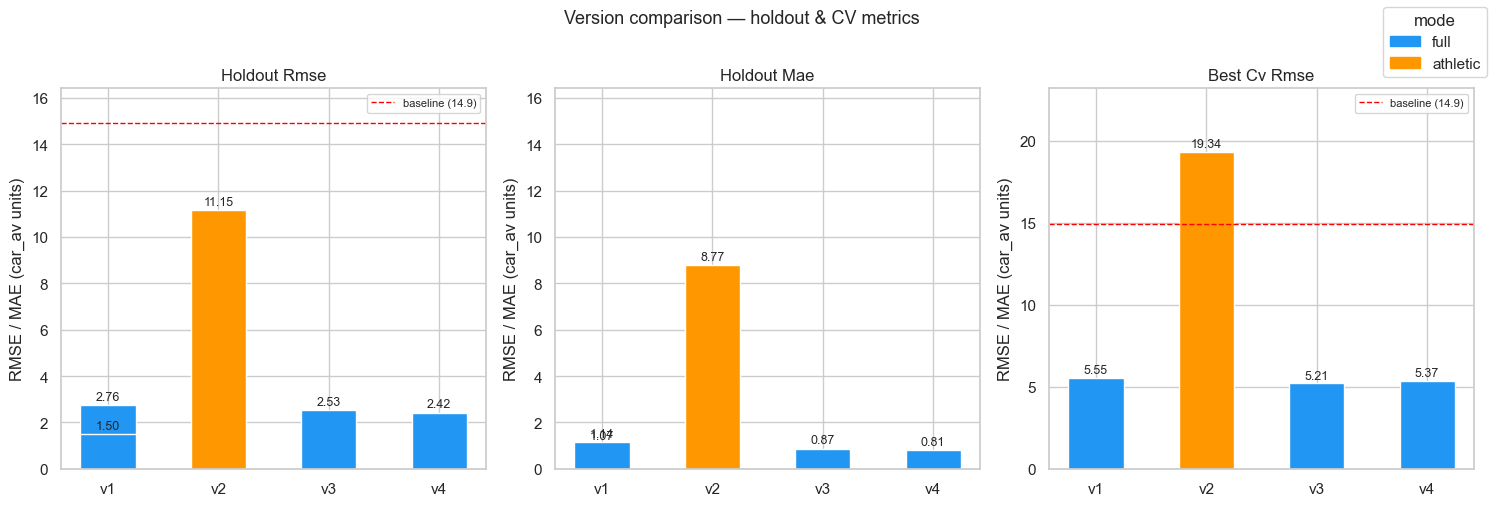

In [ ]:
# ── Metrics bar chart: all versions side-by-side ─────────────────────────────
if not compare_df.empty:
    plot_df = compare_df.reset_index()[["version", "mode", "holdout_rmse", "holdout_mae", "best_cv_rmse", "baseline_rmse"]]
    melted  = plot_df.melt(id_vars=["version", "mode"], var_name="metric", value_name="value")

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, metric in zip(axes, ["holdout_rmse", "holdout_mae", "best_cv_rmse"]):
        sub = melted[melted["metric"] == metric].copy()
        palette = {"full": "#2196F3", "athletic": "#FF9800", "unknown": "#9E9E9E"}
        bars = ax.bar(sub["version"], sub["value"],
                      color=[palette.get(m, "#9E9E9E") for m in sub["mode"]], width=0.5)
        # baseline reference line
        baseline = compare_df["baseline_rmse"].iloc[0]
        if metric in ("holdout_rmse", "best_cv_rmse"):
            ax.axhline(baseline, color="red", linestyle="--", linewidth=1, label=f"baseline ({baseline:.1f})")
            ax.legend(fontsize=8)
        for bar, val in zip(bars, sub["value"]):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                    f"{val:.2f}", ha="center", va="bottom", fontsize=9)
        ax.set_title(metric.replace("_", " ").title())
        ax.set_ylabel("RMSE / MAE (car_av units)")
        ax.set_ylim(0, max(sub["value"].max() * 1.2, baseline * 1.1))

    # Legend for mode colours
    from matplotlib.patches import Patch
    legend_handles = [Patch(color="#2196F3", label="full"), Patch(color="#FF9800", label="athletic")]
    fig.legend(handles=legend_handles, loc="upper right", title="mode")
    fig.suptitle("Version comparison — holdout & CV metrics", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()


## All-Version Comparison
Version-to-version progression: absolute metrics, delta vs v1 baseline, and % improvement over the naive mean predictor.

,version,mode,holdout_rmse,holdout_mae,best_cv_rmse,delta_rmse_vs_v1,pct_beat_baseline,n_features,n_estimators
0,v1,full,2.7590,1.0674,5.5496,+0.0000,81.5%,30,964.000000
1,v2,athletic,11.1505,8.7689,19.3426,+8.3915,25.2%,27,320.000000
2,v3,full,2.5282,0.8686,5.2092,-0.2308,83.1%,30,1999.000000
3,v4,full,2.4165,0.8083,5.3657,-0.3425,83.8%,33,1240.000000
4,v1,full,nan,nan,nan,+nan,nan%,23,nan
5,v2,full,nan,nan,nan,+nan,nan%,23,nan
6,v1,full,1.5001,1.1430,nan,-1.2589,89.9%,4,nan


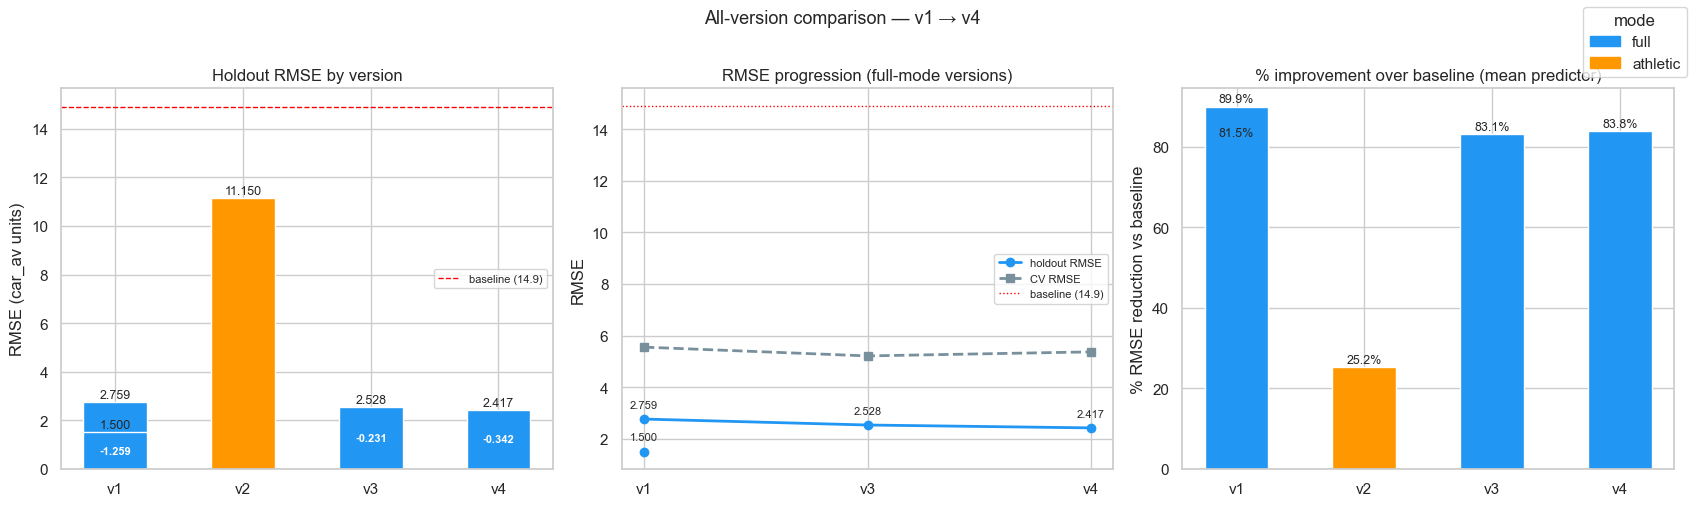

In [ ]:
# ── All-version comparison ────────────────────────────────────────────────────
rows = []
for run in artifact_dirs:
    meta = load_metadata(run)
    if not meta:
        continue
    rows.append({
        "version":      meta.get("version", run.name),
        "mode":         meta.get("mode", "full"),
        "holdout_rmse": meta.get("holdout_rmse"),
        "holdout_mae":  meta.get("holdout_mae"),
        "best_cv_rmse": meta.get("best_cv_rmse"),
        "baseline_rmse":meta.get("baseline_rmse"),
        "n_estimators": meta.get("n_estimators"),
        "n_features":   len(meta.get("feature_names", [])),
    })

prog = pd.DataFrame(rows)
baseline_rmse = prog["baseline_rmse"].iloc[0]

# Deltas vs v1 (first full-mode version)
v1_rmse = prog.loc[prog["version"] == "v1", "holdout_rmse"].values[0]
v1_mae  = prog.loc[prog["version"] == "v1", "holdout_mae"].values[0]
prog["delta_rmse_vs_v1"] = prog["holdout_rmse"] - v1_rmse
prog["delta_mae_vs_v1"]  = prog["holdout_mae"]  - v1_mae
prog["pct_beat_baseline"] = (1 - prog["holdout_rmse"] / baseline_rmse) * 100

# ── Summary table ─────────────────────────────────────────────────────────────
display_cols = ["version", "mode", "holdout_rmse", "holdout_mae", "best_cv_rmse",
                "delta_rmse_vs_v1", "pct_beat_baseline", "n_features", "n_estimators"]
styled = (prog[display_cols]
    .style
    .format({
        "holdout_rmse":       "{:.4f}",
        "holdout_mae":        "{:.4f}",
        "best_cv_rmse":       "{:.4f}",
        "delta_rmse_vs_v1":   "{:+.4f}",
        "pct_beat_baseline":  "{:.1f}%",
    })
    .background_gradient(subset=["holdout_rmse", "holdout_mae", "best_cv_rmse"],
                         cmap="RdYlGn_r", axis=0)
    .background_gradient(subset=["delta_rmse_vs_v1"], cmap="RdYlGn_r", axis=0)
)
display(styled)

# ── Progression charts ────────────────────────────────────────────────────────
full_df = prog[prog["mode"] == "full"].copy()
palette = {"full": "#2196F3", "athletic": "#FF9800"}

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# 1. Holdout RMSE progression
ax = axes[0]
for _, row in prog.iterrows():
    ax.bar(row["version"], row["holdout_rmse"],
           color=palette.get(row["mode"], "#9E9E9E"), width=0.5)
    ax.text(row["version"], row["holdout_rmse"] + 0.05,
            f"{row['holdout_rmse']:.3f}", ha="center", va="bottom", fontsize=9)
ax.axhline(baseline_rmse, color="red", linestyle="--", linewidth=1,
           label=f"baseline ({baseline_rmse:.1f})")
# delta annotations for full-mode versions only
for _, row in full_df.iterrows():
    if row["delta_rmse_vs_v1"] != 0:
        ax.text(row["version"], row["holdout_rmse"] / 2,
                f"{row['delta_rmse_vs_v1']:+.3f}", ha="center", va="center",
                fontsize=8, color="white", fontweight="bold")
ax.set_title("Holdout RMSE by version")
ax.set_ylabel("RMSE (car_av units)")
ax.legend(fontsize=8)

# 2. RMSE trend line (full-mode only)
ax = axes[1]
ax.plot(full_df["version"], full_df["holdout_rmse"],
        marker="o", linewidth=2, color="#2196F3", label="holdout RMSE")
ax.plot(full_df["version"], full_df["best_cv_rmse"],
        marker="s", linewidth=2, linestyle="--", color="#78909C", label="CV RMSE")
ax.axhline(baseline_rmse, color="red", linestyle=":", linewidth=1,
           label=f"baseline ({baseline_rmse:.1f})")
for _, row in full_df.iterrows():
    ax.annotate(f"{row['holdout_rmse']:.3f}",
                (row["version"], row["holdout_rmse"]),
                textcoords="offset points", xytext=(0, 8), ha="center", fontsize=8)
ax.set_title("RMSE progression (full-mode versions)")
ax.set_ylabel("RMSE")
ax.legend(fontsize=8)

# 3. % improvement over baseline
ax = axes[2]
for _, row in prog.iterrows():
    ax.bar(row["version"], row["pct_beat_baseline"],
           color=palette.get(row["mode"], "#9E9E9E"), width=0.5)
    ax.text(row["version"], row["pct_beat_baseline"] + 0.3,
            f"{row['pct_beat_baseline']:.1f}%", ha="center", va="bottom", fontsize=9)
ax.set_title("% improvement over baseline (mean predictor)")
ax.set_ylabel("% RMSE reduction vs baseline")

from matplotlib.patches import Patch
fig.legend(handles=[Patch(color="#2196F3", label="full"), Patch(color="#FF9800", label="athletic")],
           loc="upper right", title="mode")
plt.suptitle("All-version comparison — v1 → v4", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [34]:
# SHAP feature importance — one panel per version
import shap

fig, axes = plt.subplots(1, len(artifact_dirs), figsize=(7 * len(artifact_dirs), 6))
if len(artifact_dirs) == 1:
    axes = [axes]

for ax, run in zip(axes, artifact_dirs):
    meta  = load_metadata(run) or {}
    model = load_model(run)
    feat_df = load_feature_data(run)
    version = meta.get("version", run.name)
    mode    = meta.get("mode", "?")

    if model is None or feat_df is None:
        ax.set_title(f"{version} — no model/features")
        continue

    feature_cols = (meta.get("feature_names")
                    or (list(model.feature_names_in_) if hasattr(model, "feature_names_in_") else []))
    feature_cols = [c for c in feature_cols if c in feat_df.columns]

    sample = (feat_df[feature_cols]
              .sample(n=min(500, len(feat_df)), random_state=42)
              .astype(float)
              .reset_index(drop=True))
    try:
        explainer = shap.Explainer(model, sample)
        sv = explainer(sample)
        mean_abs = np.abs(sv.values).mean(axis=0)
    except Exception:
        # fallback: native XGBoost pred_contribs
        import xgboost as xgb
        dm = xgb.DMatrix(sample, feature_names=feature_cols)
        contribs = model.get_booster().predict(dm, pred_contribs=True)
        mean_abs = np.abs(contribs[:, :-1]).mean(axis=0)

    fi = (pd.DataFrame({"feature": feature_cols, "mean_|SHAP|": mean_abs})
          .sort_values("mean_|SHAP|", ascending=True)
          .tail(15))

    ax.barh(fi["feature"], fi["mean_|SHAP|"], color="#2196F3" if mode == "full" else "#FF9800")
    ax.set_title(f"{version}  [{mode}]\nRMSE={meta.get('holdout_rmse','?')}", fontsize=10)
    ax.set_xlabel("mean(|SHAP|)")
    ax.tick_params(axis="y", labelsize=8)

plt.suptitle("SHAP feature importance by version", fontsize=13)
plt.tight_layout()
plt.show()
print(f"Saved → {OUTPUT_DIR / 'shap_comparison.png'}")

 98%|===================| 489/500 [00:41<00:00]        

## CV / Holdout Gap Investigation

=== Target stats by split ===
  CV era     (2000–2020)  n=4053  mean=20.51  std=23.13  median=12.00
  Holdout    (nan–nan)  n=   0  mean=nan  std=nan  median=nan

=== draft_value_score by split ===
  CV era    mean=0.10  std=0.98
  Holdout   mean=nan  std=nan


/var/folders/t8/_2vv47_s12d49vpmvrkng3c80000gn/T/ipykernel_23450/3318831878.py:42: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=hold_df, x=target_col, label="Holdout era", fill=True, alpha=0.5, ax=ax)
/var/folders/t8/_2vv47_s12d49vpmvrkng3c80000gn/T/ipykernel_23450/3318831878.py:52: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=hold_df, x=dv_col, label="Holdout era", fill=True, alpha=0.5, ax=ax)


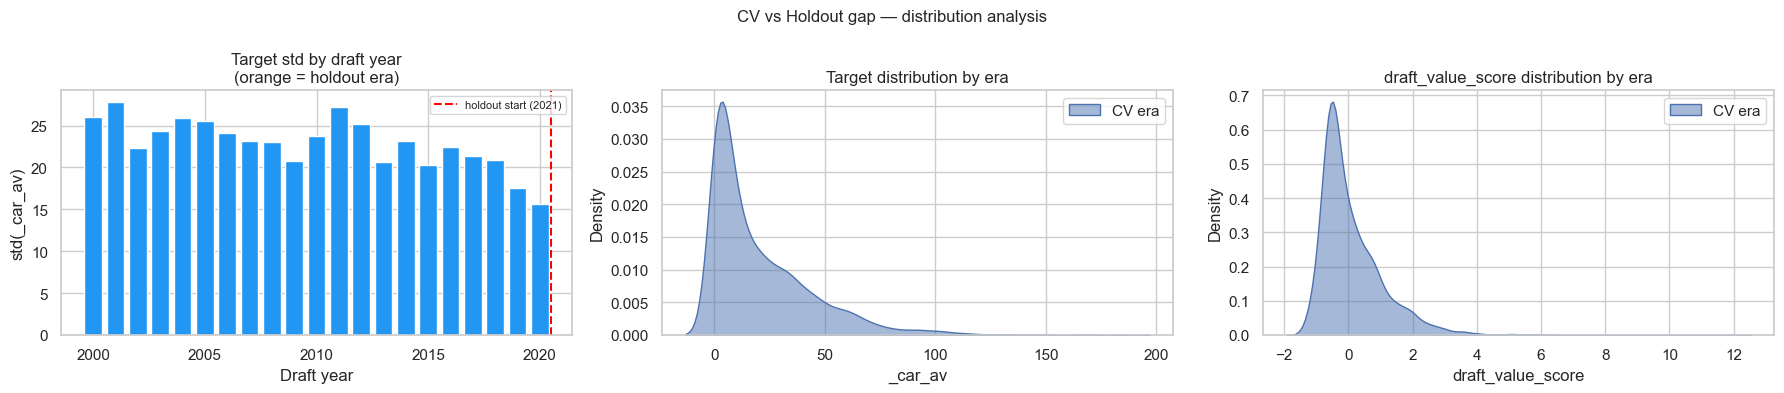


=== Fold / holdout year overlap check ===
  Clean split. CV years: [np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]
  Holdout years:         []


In [ ]:
#  CV / Holdout gap investigation 
meta     = load_metadata(selected_artifact_dir)
feat_df  = load_feature_data(selected_artifact_dir)
target_col = "_car_av"
year_col   = "draft_year"

if feat_df is not None and meta is not None:
    feat_df = feat_df.reset_index()

    folds = meta.get("folds", [])
    holdout_start = max(f["val_end"] for f in folds) + 1 if folds else 2021

    cv_df   = feat_df[feat_df[year_col] <  holdout_start]
    hold_df = feat_df[feat_df[year_col] >= holdout_start]

    #  1. Summary stats by split 
    print("=== Target stats by split ===")
    for name, df in [("CV era    ", cv_df), ("Holdout   ", hold_df)]:
        yrs = f"{df[year_col].min()}–{df[year_col].max()}"
        print(f"  {name} ({yrs})  n={len(df):>4}  "
              f"mean={df[target_col].mean():.2f}  "
              f"std={df[target_col].std():.2f}  "
              f"median={df[target_col].median():.2f}")

    # ── 2. Per-year target std ────────────────────────────────────────────────
    by_year = feat_df.groupby(year_col)[target_col].agg(["mean", "std", "count"])

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    ax = axes[0]
    colors = ["#FF9800" if y >= holdout_start else "#2196F3" for y in by_year.index]
    ax.bar(by_year.index, by_year["std"], color=colors)
    ax.axvline(holdout_start - 0.5, color="red", linestyle="--", label=f"holdout start ({holdout_start})")
    ax.set_title("Target std by draft year\n(orange = holdout era)")
    ax.set_xlabel("Draft year")
    ax.set_ylabel(f"std({target_col})")
    ax.legend(fontsize=8)

    # ── 3. KDE: CV vs holdout target distribution ─────────────────────────────
    ax = axes[1]
    sns.kdeplot(data=cv_df,   x=target_col, label="CV era",      fill=True, alpha=0.5, ax=ax)
    sns.kdeplot(data=hold_df, x=target_col, label="Holdout era", fill=True, alpha=0.5, ax=ax)
    ax.set_title("Target distribution by era")
    ax.set_xlabel(target_col)
    ax.legend()

    # ── 4. draft_value_score distribution across eras ─────────────────────────
    ax = axes[2]
    dv_col = "draft_value_score"
    if dv_col in feat_df.columns:
        sns.kdeplot(data=cv_df,   x=dv_col, label="CV era",      fill=True, alpha=0.5, ax=ax)
        sns.kdeplot(data=hold_df, x=dv_col, label="Holdout era", fill=True, alpha=0.5, ax=ax)
        ax.set_title(f"{dv_col} distribution by era")
        ax.set_xlabel(dv_col)
        ax.legend()

        print("\n=== draft_value_score by split ===")
        for name, df in [("CV era  ", cv_df), ("Holdout ", hold_df)]:
            print(f"  {name}  mean={df[dv_col].mean():.2f}  std={df[dv_col].std():.2f}")

    plt.suptitle("CV vs Holdout gap — distribution analysis", fontsize=12)
    plt.tight_layout()
    plt.show()

    # ── 5. Leakage check: any holdout years inside CV folds? ─────────────────
    print("\n=== Fold / holdout year overlap check ===")
    holdout_years = set(hold_df[year_col].unique())
    cv_years      = set(cv_df[year_col].unique())
    overlap = holdout_years & cv_years
    if overlap:
        print(f"  WARNING — overlapping years: {sorted(overlap)}")
    else:
        print(f"  Clean split. CV years: {sorted(cv_years)}")
        print(f"  Holdout years:         {sorted(holdout_years)}")

## Secondary Signal Analysis: `weight_lbs` & `speed_score`
These features have low SHAP values in v3. Before engineering new features from them, check whether they carry **any** non-linear signal or position-specific correlation with the target.

=== Global correlation with target ===
  weight_lbs: r=0.120
  speed_score: r=0.062
  agility_score: r=0.124
  burst_score: r=0.124


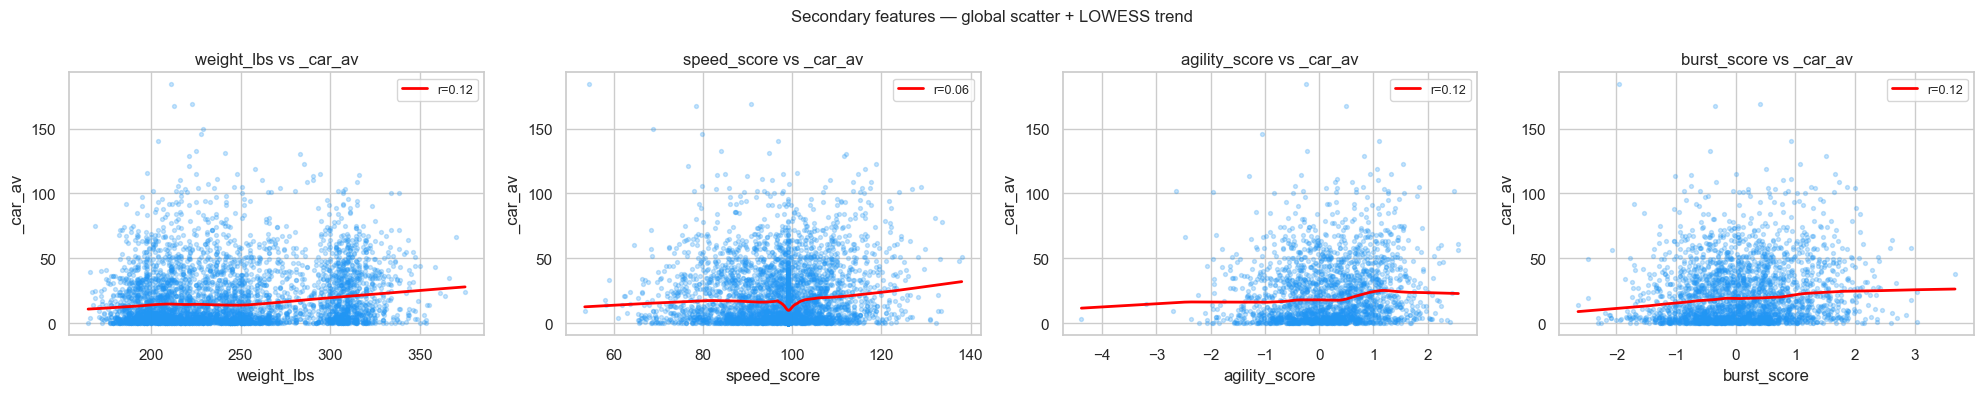


=== Correlation by position group ===


feature,agility_score,burst_score,speed_score,weight_lbs
position,,,,
DB,0.133,0.123,0.164,0.077
DL,0.107,0.121,0.178,0.056
LB,0.166,0.183,0.222,0.094
OL,0.236,0.208,0.072,0.011
QB,0.105,0.092,-0.040,-0.018
SKILL,0.047,0.099,0.205,-0.079
SPEC,0.720,0.819,-0.339,0.081



=== Engineering verdict ===
Flag features with |r| > 0.15 by position as candidates for interaction terms:
  SKILL × speed_score: r=0.205  → consider pos_SKILL * speed_score
  OL × agility_score: r=0.236  → consider pos_OL * agility_score
  OL × burst_score: r=0.208  → consider pos_OL * burst_score
  DL × speed_score: r=0.178  → consider pos_DL * speed_score
  LB × speed_score: r=0.222  → consider pos_LB * speed_score
  LB × agility_score: r=0.166  → consider pos_LB * agility_score
  LB × burst_score: r=0.183  → consider pos_LB * burst_score
  DB × speed_score: r=0.164  → consider pos_DB * speed_score
  SPEC × speed_score: r=-0.339  → consider pos_SPEC * speed_score
  SPEC × agility_score: r=0.720  → consider pos_SPEC * agility_score
  SPEC × burst_score: r=0.819  → consider pos_SPEC * burst_score


In [ ]:
from statsmodels.nonparametric.smoothers_lowess import lowess

feat_df  = load_feature_data(selected_artifact_dir)
target_col = "_car_av"
year_col   = "draft_year"
SECONDARY  = ["weight_lbs", "speed_score", "agility_score", "burst_score"]

if feat_df is not None:
    feat_df = feat_df.reset_index()
    secondary = [c for c in SECONDARY if c in feat_df.columns]

    # ── 1. Global correlation + LOWESS scatter ────────────────────────────────
    fig, axes = plt.subplots(1, len(secondary), figsize=(5 * len(secondary), 4))
    axes = [axes] if len(secondary) == 1 else list(axes)

    print("=== Global correlation with target ===")
    for ax, col in zip(axes, secondary):
        valid = feat_df[[col, target_col]].dropna()
        r = valid.corr().iloc[0, 1]
        print(f"  {col}: r={r:.3f}")

        ax.scatter(valid[col], valid[target_col], alpha=0.25, s=8, color="#2196F3")
        trend = lowess(valid[target_col], valid[col], frac=0.35)
        ax.plot(trend[:, 0], trend[:, 1], color="red", linewidth=2, label=f"r={r:.2f}")
        ax.set_xlabel(col)
        ax.set_ylabel(target_col)
        ax.set_title(f"{col} vs {target_col}")
        ax.legend(fontsize=9)

    plt.suptitle("Secondary features — global scatter + LOWESS trend", fontsize=12)
    plt.tight_layout()
    plt.show()

    # ── 2. Correlation by position group ─────────────────────────────────────
    pos_cols = [c for c in feat_df.columns if c.startswith("pos_")]
    records  = []
    for pos in pos_cols:
        sub = feat_df[feat_df[pos] == 1]
        if len(sub) < 20:
            continue
        for col in secondary:
            if col in sub.columns:
                r = sub[[col, target_col]].dropna().corr().iloc[0, 1]
                records.append({"position": pos.replace("pos_", ""), "feature": col, "r": round(r, 3)})

    if records:
        corr_pos = pd.DataFrame(records).pivot(index="position", columns="feature", values="r")
        print("\n=== Correlation by position group ===")
        display(corr_pos.style.background_gradient(cmap="RdYlGn", axis=None, vmin=-0.5, vmax=0.5)
                              .format("{:.3f}"))

    # ── 3. Engineering verdict ────────────────────────────────────────────────
    print("\n=== Engineering verdict ===")
    print("Flag features with |r| > 0.15 by position as candidates for interaction terms:")
    for rec in records:
        if abs(rec["r"]) > 0.15:
            print(f"  {rec['position']} × {rec['feature']}: r={rec['r']:.3f}  → consider pos_{rec['position']} * {rec['feature']}")